# Question 1

### Question b

                -2.142  -1.071   0.000   1.071   2.142  row_sum
current → next                                                 
-2.142          0.8982  0.1001  0.0018  0.0000  0.0000   1.0001
-1.071          0.0464  0.6164  0.3314  0.0059  0.0000   1.0001
0.000           0.0008  0.1460  0.7064  0.1460  0.0008   1.0000
1.071           0.0000  0.0059  0.3314  0.6164  0.0464   1.0001
2.142           0.0000  0.0000  0.0000  0.0074  0.9926   1.0000
Simulated z_t:
 [-2.14242853 -2.14242853 -2.14242853 ...  2.14242853  2.14242853
  2.14242853]


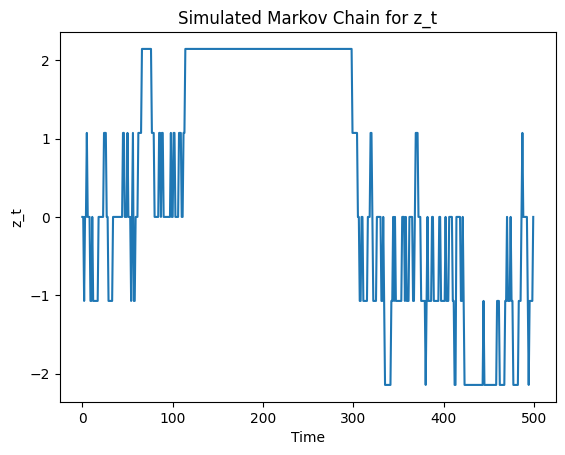

Mean of simulation: 1.0455051219386735
Standard deviation of simulation : 1.4427990296642148
Autocorrelation of simulation (lag 1): 0.9617670907220143
Theoretical Mean: 0
Theoretical Standard Deviation: 0.51
Theoretical Autocorrelation (lag 1): 0.7


In [238]:
import numpy as np
from numpy import sqrt
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd
from math import comb
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import time


# Parameters 
# Ar(1) process z_t+1 = rho*z_t + (1- rho^2) epsilon_t+1 where epsilon ~ N(0,1)
rho = 0.7
m= 3
N = 5
T = 2000 
mean_z = 0
sigma_epsilon = 1 - rho**2 # Standard deviation of epsilon
sigma_z = (1-rho**2)

# Tauchen method 
# Creating state space for (slide 28)
Z_N = m * sqrt(sigma_z)
Z_1 = - Z_N
d = (Z_N - Z_1) / (N - 1)
z_grid = np.linspace(Z_1, Z_N, N)

# Transition matrix (slide 29)
P = np.zeros((N, N))
P_i1 = norm.cdf((z_grid[0] - rho * z_grid + d / 2) / sigma_epsilon) # First row
P_iN = 1 - norm.cdf((z_grid[-1] - rho * z_grid + d / 2) / sigma_epsilon) # Last row
P_ij = np.zeros((N-2, N)) # Middle rows 
for i in range(1, N-1):
    for j in range(N):
        P_ij[i-1, j] = norm.cdf((z_grid[j] - rho * z_grid[i] + d / 2) / sigma_epsilon) - norm.cdf((z_grid[j] - rho * z_grid[i] - d / 2) / sigma_epsilon)

P[0, :] = P_i1
P[-1, :] = P_iN
P[1:-1, :] = P_ij

# Create table by using function (see below)
dfP = transition_table(z_grid, P, decimals=4)
print(dfP)

P = P / P.sum(axis=1, keepdims=True) # Normalize rows to sum to 1

# Simulate Markov Chain 
z_sim = np.zeros(T)
z_sim[0] = Z_1  # Start at the lowest state
cdf = np.cumsum(P, axis=1)
cdf[:, -1] = 1.0

z_sim = np.empty(T)
idx = 0  # 0..N-1; e.g., 0 for lowest state
z_sim[0] = z_grid[idx]

u = np.random.rand(T-1)  # in [0,1)
for t in range(1, T):
    idx = np.searchsorted(cdf[idx], u[t-1], side="right")
    z_sim[t] = z_grid[idx]
print("Simulated z_t:\n", z_sim)

# Discard first 500 observations 
z_sim = z_sim[500:]

# Plot the simulated series
plt.plot(z_sim[:500]) #Only first 500 for better visibility
plt.title('Simulated Markov Chain for z_t')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()
 
# Compute statistics for the simulated series
mean_z_sim = np.mean(z_sim)
std_z_sim = np.std(z_sim)
autocorr_z_sim = np.corrcoef(z_sim[:-1], z_sim[1:])[0, 1]

print("Mean of simulation:", mean_z_sim)
print("Standard deviation of simulation :", std_z_sim)
print("Autocorrelation of simulation (lag 1):", autocorr_z_sim)

# Theoretical moments (see slide 31)
theoretical_mean = mean_z
theoretical_var = (1-rho**2)**2
theoretical_corr = rho 

print("Theoretical Mean:", theoretical_mean)
print("Theoretical Standard Deviation:", sqrt(theoretical_var))
print("Theoretical Autocorrelation (lag 1):", theoretical_corr)





### Question c

                -1.428  -0.714   0.000   0.714   1.428  row_sum
current → next                                                 
-1.428          0.5220  0.3685  0.0975  0.0115  0.0005   1.0000
-0.714          0.0921  0.5708  0.2850  0.0493  0.0029   1.0001
0.000           0.0163  0.1900  0.5875  0.1900  0.0163   1.0001
0.714           0.0029  0.0493  0.2850  0.5708  0.0921   1.0001
1.428           0.0005  0.0115  0.0975  0.3685  0.5220   1.0000
Simulated z_t (Rouwenhorst):
 [-1.42828569 -0.71414284 -0.71414284 ...  0.          0.
  0.        ]


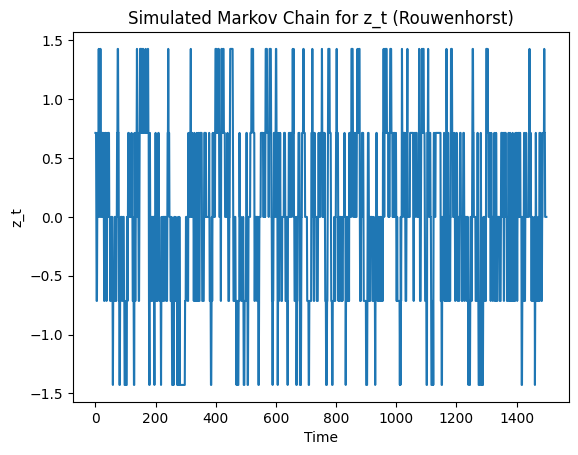

Mean of simulation (Rouwenhorst): 0.024756951885615233
Standard deviation of simulation (Rouwenhorst): 0.7403695653748426
Autocorrelation of simulation (lag 1) (Rouwenhorst): 0.7359982823603964


In [ ]:
# Rouwenhorst method 
# here sgima_e =1
std_Z = sqrt(1-rho**2)

# Construct markov chain
def rouwenhorst(N, rho, sigma_epsilon, std_Z):
    p = (1 + rho) / 2 #Becasue zero mean (see slide 38)
    q = p
    s = (1-p) / (2-(p+q))
    psi = sqrt(N-1) * std_Z #See slide 37-39 how to compute
    
    # Initial transition matrix for N=2 #Slide 36
    P = np.array([[p, 1 - p],
                  [1 - q, q]])
    
    # Recursive construction for N>2 #Slide 36
    for n in range(3, N + 1):
        P_new = np.zeros((n, n))
        P_new[:-1, :-1] += p * P
        P_new[:-1, 1:] += (1 - p) * P
        P_new[1:, :-1] += (1 - q) * P
        P_new[1:, 1:] += q * P
        
        if n > 2:
            P_new[1:-1, :] /= 2.0
        
        P = P_new

    # State space
    z_grid = np.linspace(-psi, psi, N)

    P /= P.sum(axis=1, keepdims=True) # Normalize rows to sum to 1
    
    return p, s,z_grid, P
 
p, s, z_grid_r, P_r = rouwenhorst(N, rho, sigma_epsilon, std_Z)


# Create table by using function (see below)
dfP = transition_table(z_grid_r, P_r, decimals=4)
print(dfP)

P_r = P_r / P_r.sum(axis=1, keepdims=True) #Nromalize 

# Simulate Markov Chain using Rouwenhorst method
z_sim_r = np.zeros(T)
z_sim_r[0] = Z_1  # Start at the lowest state
cdf_r = np.cumsum(P_r, axis=1)
cdf_r[:, -1] = 1.0
z_sim_r = np.empty(T)
idx = 0

z_sim_r[0] = z_grid_r[idx]
u_r = np.random.rand(T-1)  # in [0,1)
for t in range(1, T):
    idx = np.searchsorted(cdf_r[idx], u_r[t-1], side="right")
    z_sim_r[t] = z_grid_r[idx]
print("Simulated z_t (Rouwenhorst):\n", z_sim_r)

# Discard first 500 observations
z_sim_r = z_sim_r[500:]

# Plot the simulated series
plt.plot(z_sim_r)
plt.title('Simulated Markov Chain for z_t (Rouwenhorst)')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()

# Compute statistics for the simulated series
mean_z_sim_r = np.mean(z_sim_r)
std_z_sim_r = np.std(z_sim_r)
autocorr_z_sim_r = np.corrcoef(z_sim_r[:-1], z_sim_r[1:])[0, 1]
print("Mean of simulation (Rouwenhorst):", mean_z_sim_r)
print("Standard deviation of simulation (Rouwenhorst):", std_z_sim_r)
print("Autocorrelation of simulation (lag 1) (Rouwenhorst):", autocorr_z_sim_r)


### Quesiton D
Repeat b and c with different value for rho

## Question 2

### Question a

[[0.7225 0.255  0.0225]
 [0.1275 0.745  0.1275]
 [0.0225 0.255  0.7225]]
State space for y: [-1.98029509  0.          1.98029509]
State space for z = exp(y): [0.1380285  1.         7.24488053]
                 0.138  1.000   7.245  row_sum
current → next                                
0.138           0.7225  0.255  0.0225      1.0
1.000           0.1275  0.745  0.1275      1.0
7.245           0.0225  0.255  0.7225      1.0
[0.25 0.5  0.25]


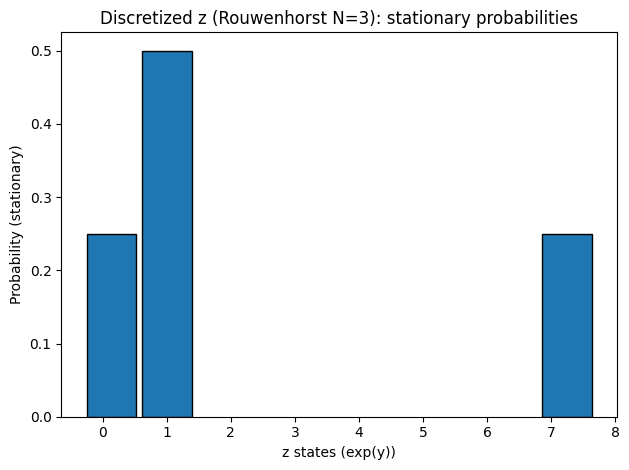

In [245]:
# Strategy: Discredize y and then set z = exp(y) on grid
# Because y still has a symetric distribution but z does not 
sigma_e = 1 
Nz = 3
rho = 0.7 

std_Y = sigma_e / sqrt(1-rho**2)

# Y has zero mean thus can use function from question 1c
p, s, y_grid_r, P_r2 = rouwenhorst(Nz, rho, sigma_e, std_Y)
print(P_r2)

# Transform to z = exp(y)
z_grid_exp = np.exp(y_grid_r)
print("State space for y:", y_grid_r)
print("State space for z = exp(y):", z_grid_exp)

# Create a table for transition probabilities
dfP = transition_table(z_grid_exp, P_r2, decimals=4)
print(dfP)

def stationary_dist_binomial(N, p, q):
    s = (1 - p) / (2 - (p + q))
    pi = np.array([comb(N-1, i) * (s**i) * ((1-s)**(N-1-i)) for i in range(N)], float)
    return pi / pi.sum()

# Example: rho=0.7 
q = p  
pi_cf = stationary_dist_binomial(3, p, q)   
print(pi_cf)

# --- bar width: smaller than nearest spacing to avoid overlap ---
x = np.asarray(z_grid_exp, float)
xs = np.sort(x)
dx = np.diff(xs)
w = 0.9 * dx.min() if dx.size else 0.1

# --- plot ---
plt.figure()
plt.bar(x, pi_cf, width=w, align='center', edgecolor='k')
plt.xlabel('z states (exp(y))')
plt.ylabel('Probability (stationary)')
plt.title('Discretized z (Rouwenhorst N=3): stationary probabilities')
plt.tight_layout()

# Save to folder 
out_dir = Path.cwd() / "output"       
out_dir.mkdir(parents=True, exist_ok=True)
fname = f"Q2a" #Filename 

plt.savefig(out_dir / f"{fname}.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / f"{fname}.pdf", bbox_inches="tight")    
plt.show()


### Question b

In [ ]:
# Solving the Bellman equation 
beta = 0.96
alpha = 0.30
delta = 0.1
k_stst = ((1-beta + beta*delta)/(alpha*beta))**(1/(alpha-1))
c_stst = k_stst**alpha - delta*k_stst
print("Steady state capital k*:", k_stst)


k_upper = 1.5 * k_stst
k_lower = 0.5 * k_stst
N_k = 1000
k_grid = np.linspace(k_lower, k_upper, N_k)

# Create utility function
def utility(c):
    u = np.full_like(c, -np.inf, dtype=float)
    mask = c > 0
    u[mask] = np.log(c[mask])
    return u

# Value function iteration
Nz = len(z_grid_exp)
Nk = len(k_grid)
V  = np.zeros((Nk, Nz))    
V_new = np.empty_like(V)
pol_kp_idx = np.zeros((Nk, Nz), dtype=int)

t0 = time.perf_counter()
for iteration in range(1000):
    
    #print(f"Iteration: {iteration}")
    EV = V @ P_r2.T  # Expected value function

    """" Idea: 
        Step1: For each z, we compute the value function over all k and k' pairs and then maximize
        thus given a z we get a Nk * Nk matrix with (k,k') pairs. 
        Step 2: For each pair in the matrix we compute consumption and its utility. 
        We then pick the best column for every row. Thus we get a vector of 
        lenght NK with the best value for each k given z.
        Step 3: We repeat this process for every z and fill the V_new matrix column by column
        Step 4: We continue this process until convergence. 
        
        """""


    for iz, z in enumerate(z_grid_exp):
        R = z * k_grid**alpha + (1 - delta) * k_grid # Return (Nk*1) vector for current k and z 
        c = R[:, None] - k_grid[None, :]  # Consumption matrix for all (k,k') pairs
        u = utility(c)  # Utility matrix for all (k,k') pairs
        val = u + beta * EV[:, iz][None, :]  # Total value matrix for all (k,k') pairs

        #Maximize 
        best_idx = np.argmax(val, axis=1) # Index of best k' for each k. Picks the row-wise maximum
        V_new[:, iz] = val[np.arange(Nk), best_idx] # fill the iz-th column of V_new
        pol_kp_idx[:, iz] = best_idx
        kprime_policy = k_grid[pol_kp_idx]

    if np.max(np.abs(V_new - V)) < 1e-6:
        break
    V[:] = V_new
    elapsed = time.perf_counter() - t0




Steady state capital k*: 2.9208221499640716


In [ ]:
# ----- Diagnostics
# 1. Time
print(f"Converged in {iteration} iterations.")
print("Elapsed time:", elapsed, "seconds")

# 2. Euler equation errros
# Euler equation error computation
# Here is take the full grid maximum
""" EEE(k) = log_10 |1-  (c(k'(k)) / ([beta[1+ alpha * E(z') * k'(k)^(alpha-1) - delta]*c(k))) |"""
    
EEE = euler_errors(k_grid, z_grid_exp, P_r2, pol_kp_idx, alpha, beta, delta)
print("max Euler error (log10):", np.nanmax(EEE))

# Quick summary
print("max log10 error:", np.nanmax(EEE))
print("median log10 error:", np.nanmedian(EEE))

# Example: mask NaNs (infeasible) and show a few entries
valid = np.isfinite(EEE)
print("min (valid) log10 error:", np.nanmin(EEE[valid]))

#3. Bellman residuals
# Ensure P is row-stochastic
P = P_r2 / P_r2.sum(axis=1, keepdims=True)

Nk, Nz = len(k_grid), len(z_grid_exp)
k = k_grid
k_col = k_grid[:, None]           # (Nk,1)
z_row = z_grid_exp[None, :]       # (1,Nz)

def utility_pos(c):
    u = np.full_like(c, -np.inf, dtype=float)
    m = c > 0
    u[m] = np.log(c[m])
    return u

# Expected value for each (k', z): EV(k',z) using current V
EV = V @ P.T                      # (Nk, Nz)

#Optimal Bellman residual
TV_opt = np.empty_like(V)

for iz, zval in enumerate(z_grid_exp):
    R = zval * k**alpha + (1 - delta) * k                # (Nk,)
    c = R[:, None] - k_grid[None, :]                     # (Nk, Nk): all (k,k')
    u = utility_pos(c)                                   # (Nk, Nk)
    # add continuation value at k' for current z
    val = u + beta * EV[:, iz][None, :]                  # (Nk, Nk)
    TV_opt[:, iz] = np.max(val, axis=1)                  # (Nk,)

opt_residual = np.abs(TV_opt - V)
opt_sup = np.max(opt_residual)
opt_mean = np.mean(opt_residual)
print("Bellman optimal residual (sup):", opt_sup)
print("Bellman optimal residual mean:", opt_mean)
print("Value error bound opt_residual/(1-beta):", opt_sup / (1 - beta))

# Store results for table 
time_VFI = elapsed
Bellman_residual_VFI = opt_sup
Bellman_residual_mean_VFI = opt_mean
EEE_median_VFI = np.nanmedian(EEE)
EEE_min_VFI = np.nanmin(EEE)
EEE_max_VFI = np.nanmax(EEE)



Converged in 292 iterations.
Elapsed time: 5.665505249984562 seconds
max Euler error (log10): -0.1432109800228154
max log10 error: -0.1432109800228154
median log10 error: -2.4124882035367827
min (valid) log10 error: -6.431758293141097
Bellman optimal residual (sup): 9.238868319272342e-07
Bellman optimal residual mean: 9.238868282248069e-07
Value error bound opt_residual/(1-beta): 2.3097170798180835e-05
Bellman optimal residual (sup): 9.238868319272342e-07
Bellman optimal residual mean: 9.238868282248069e-07


### Policy function iteration

In [ ]:
N_z = 3 # If you want to change the number of z states
p, s, y_grid_r, P_r2 = rouwenhorst(Nz, rho, sigma_e, std_Y)
print(P_r2)

# Transform to z = exp(y)
z_grid_exp = np.exp(y_grid_r)

# --- dimensions ---
Nz = len(z_grid_exp)
Nk = len(k_grid)

# --- initial policy indices (Nk x Nz) ---
# initialize something feasible (consume a fixed share):
Kp0 = 0.1*(z_grid_exp[None,:]*k_grid[:,None]**alpha + (1-delta)*k_grid[:,None])  # safe
pol_kp_idx = proj_to_grid(Kp0, k_grid)

# --- cached arrays for broadcasting ---
k = k_grid[:, None]                   # (Nk,1)
z = z_grid_exp[None, :]               # (1,Nz)
ones_k = np.ones((Nk,1))
ones_z = np.ones((1,Nz))

# Parameters for PFI
tol = 1e-6
maxit = 10000
c_floor   = 1e-6       # consumption floor
rhs_floor = 1e-10      # RHS floor
omega     = 0.15       #damping

t0 = time.perf_counter()
for it in range(maxit):
    # current policy as levels (Nk x Nz)
    Kp = k_grid[pol_kp_idx] #This is guessed k' policy

    # current consumption today c(k,z) (Nk x Nz)
    # For each combination of (k,z) compute C
    resources = z*k**alpha + (1-delta)*k              
    c_now = z*k**alpha + (1-delta)*k - Kp # Nk x Nz
    c_now = np.maximum(c_now, c_floor)   # guard against nonpositive consumption

    # compute RHS of Euler 
    # For each z' (index j), we need:
    #   k' = Kp (Nk x Nz) (The guessed next capital from current policy)
    #   k'' = policy at next state

    # next-period k' indices (Nk x Nz)
    kp_idx = pol_kp_idx

    # prepare container for the z' dimension (Nk x Nz x Nz)
    # Because we have a combination of (k,z) today and for each z' we compute next period values
    term = np.empty((Nk, Nz, Nz), dtype=float)

    for j in range(Nz):
        # map (i, z_cur) -> next policy index when tomorrow's shock is z'_j:
        # next_idx[i, z_cur] = pol_kp_idx[ kp_idx[i, z_cur], j ]

        col_j = pol_kp_idx[:, j]               # (Nk,)
        next_idx = pol_kp_idx[kp_idx, j]       # (Nk, Nz)
        Kpp = k_grid[next_idx]                 # (Nk, Nz)

        zprime = z_grid_exp[j]
        kprime = Kp                            # (Nk, Nz)
        c_next = zprime * (kprime**alpha) + (1-delta)*kprime - Kpp # (Nk, Nz)
        c_next = np.maximum(c_next, c_floor)     

        # For each z' store the RHS term of Euler within the expectation
        mnext = (zprime*alpha*(kprime**(alpha-1)) + (1-delta)) / c_next  # (Nk, Nz)
        term[:, :, j] = mnext

    # weight across z' by transition probs P(z_cur, z')
    # P_r2 assumed shape (Nz, Nz), row-stochastic
    # Broadcast P over Nk: (1,Nz,Nz) * (Nk,Nz,Nz)
    # Compute RHS of Euler equation, Then reshape into (Nk,Nz)
    RHS = beta * np.sum(term * P_r2[None, :, :], axis=2)   # (Nk, Nz) we are summing over the 3rd dimension z'
    RHS = np.maximum(RHS, rhs_floor)                       # avoid 1/0

    # Euler update 
    c_new = 1.0 / RHS
    Kp_cont = resources - c_new    
    
    # enforce feasibility k' ∈ [k_min, resources - c_floor]
    Kp_cont = np.minimum(Kp_cont, resources - c_floor)
    Kp_cont = np.maximum(Kp_cont, k_grid[0])

    # Damping 
    # This helps to stabilize the iteration
    Kp_cont = omega*Kp_cont + (1-omega)*(k_grid[pol_kp_idx])

    pol_kp_idx_new = proj_to_grid(Kp_cont, k_grid) # project to grid -> new indices

    # ensure tomorrow-feasibility c(k', z') >= c_floor for all z' ---
    kp_idx_new = pol_kp_idx_new                    # (Nk, Nz) row indices of k' (for current policy)
    Kp_now     = k_grid[kp_idx_new]                # (Nk, Nz) k' in levels today

    for j in range(Nz):
        zprime = z_grid_exp[j]
        res_next_j = zprime*(Kp_now**alpha) + (1-delta)*Kp_now - c_floor    # max feasible k'' to keep c_next>=c_floor
        max_allowed_idx = proj_to_grid(np.minimum(res_next_j, k_grid[-1]), k_grid)  # (Nk, Nz)

        next_idx = pol_kp_idx_new[kp_idx_new, j]       # (Nk, Nz) current k'' indices
        next_idx_clipped = np.minimum(next_idx, max_allowed_idx)

        # write back to column j at rows = kp_idx_new
        rows = kp_idx_new.reshape(-1)
        cols = np.full(rows.shape, j, dtype=int)
        pol_kp_idx_new[rows, cols] = next_idx_clipped.reshape(-1)

    # convergence (sup over (k,z) in levels)
    diff = np.max(np.abs(k_grid[pol_kp_idx_new] - k_grid[pol_kp_idx]))
    #print(f"Euler-PFI iter {it}: sup|Δk'| = {diff:.3e}")
    pol_kp_idx_old = pol_kp_idx
    pol_kp_idx = pol_kp_idx_new

    if diff < tol:
        break
    print(f"Euler-PFI iter {it}: sup|Δk'| = {diff:.3e}")
    
    elapsed = time.perf_counter() - t0

# Final policy:
K_prime = k_grid[pol_kp_idx]   # (Nk, Nz)


[[0.7225 0.255  0.0225]
 [0.1275 0.745  0.1275]
 [0.0225 0.255  0.7225]]
Euler-PFI iter 0: sup|Δk'| = 2.921e+00
Euler-PFI iter 1: sup|Δk'| = 4.970e-02
Euler-PFI iter 2: sup|Δk'| = 8.479e-02
Euler-PFI iter 3: sup|Δk'| = 1.023e-01
Euler-PFI iter 4: sup|Δk'| = 1.374e-01
Euler-PFI iter 5: sup|Δk'| = 1.783e-01
Euler-PFI iter 6: sup|Δk'| = 1.491e-01
Euler-PFI iter 7: sup|Δk'| = 1.988e-01
Euler-PFI iter 8: sup|Δk'| = 1.842e-01
Euler-PFI iter 9: sup|Δk'| = 1.637e-01
Euler-PFI iter 10: sup|Δk'| = 1.520e-01
Euler-PFI iter 11: sup|Δk'| = 1.257e-01
Euler-PFI iter 12: sup|Δk'| = 1.316e-01
Euler-PFI iter 13: sup|Δk'| = 1.403e-01
Euler-PFI iter 14: sup|Δk'| = 1.403e-01
Euler-PFI iter 15: sup|Δk'| = 1.725e-01
Euler-PFI iter 16: sup|Δk'| = 2.017e-01
Euler-PFI iter 17: sup|Δk'| = 2.368e-01
Euler-PFI iter 18: sup|Δk'| = 2.397e-01
Euler-PFI iter 19: sup|Δk'| = 2.953e-01
Euler-PFI iter 20: sup|Δk'| = 3.099e-01
Euler-PFI iter 21: sup|Δk'| = 3.333e-01
Euler-PFI iter 22: sup|Δk'| = 3.742e-01
Euler-PFI iter 23

### Diagnostics

In [266]:
# ----- Diagnostics -----
# 1.Bellman-RESIDUAL
# Assumes you already have: k_grid, z_grid_exp, alpha, beta, delta,
#                           pol_kp_idx (Nk x Nz), P_r2 (Nz x Nz row-stochastic)

# Shapes/helpers
Nk = len(k_grid)
Nz = len(z_grid_exp)
k  = k_grid[:, None]           # (Nk, 1)
z  = z_grid_exp[None, :]       # (1,  Nz)

# Floors for numerical stability
c_floor   = 1e-6
rhs_floor = 1e-10

# Current policy in levels and consumption today c(k,z)
Kp = k_grid[pol_kp_idx]                                      # (Nk, Nz)  k'(k,z)
resources = z * (k**alpha) + (1 - delta) * k                 # (Nk, Nz)
c_now = np.maximum(resources - Kp, c_floor)                  # (Nk, Nz)

# Build RHS = beta * E_{z'|z}[ (z' α k'^{α-1} + 1-δ) / c(k', z') ]
kp_idx = pol_kp_idx                                          # (Nk, Nz)  indices of k' on k_grid
term = np.empty((Nk, Nz, Nz), dtype=float)                   # store fraction for each z'
cnext_min = np.full((Nk, Nz), np.inf)                        # track min_z' c_next for diagnostics

for j in range(Nz):
    zprime = z_grid_exp[j]
    # NEXT-PERIOD INDEXING: k'' = k'(k', z'_j)
    next_idx = pol_kp_idx[kp_idx, j]                         # (Nk, Nz)
    Kpp = k_grid[next_idx]                                   # (Nk, Nz)

    kprime = Kp                                              # (Nk, Nz)
    c_next = zprime * (kprime**alpha) + (1 - delta) * kprime - Kpp
    c_next = np.maximum(c_next, c_floor)                     # enforce positive c(k', z')

    # fraction inside expectation
    term[:, :, j] = (zprime * alpha * (kprime**(alpha - 1)) + (1 - delta)) / c_next
    cnext_min = np.minimum(cnext_min, c_next)                # diagnostic: min over z'

# Expectation over z' (sum last axis), then floor
RHS = beta * np.sum(term * P_r2[None, :, :], axis=2)         # (Nk, Nz)
RHS = np.maximum(RHS, rhs_floor)

# Euler residuals
euler_resid_mat = np.abs(1.0 / c_now - RHS)                  # (Nk, Nz)
euler_resid_sup = np.max(euler_resid_mat)
euler_resid_avg = np.mean(euler_resid_mat)

print("sup Euler residual         :", euler_resid_sup)
print("avg Euler residual         :", euler_resid_avg)
print("min c_now                  :", float(c_now.min()))
print("min over z' of c_next      :", float(cnext_min.min()))
print("rowsum(P) (should be ~1.0) :", P_r2.sum(axis=1))

# 2. EULER EQUATION ERRORS
EEE = euler_errors(
    k_grid=k_grid,
    z_grid=z_grid_exp,
    P=P_r2,
    pol_kp_idx=pol_kp_idx,
    alpha=alpha,
    beta=beta,
    delta=delta
)

# Quick summary
print("max log10 error:", np.nanmax(EEE))
print("median log10 error:", np.nanmedian(EEE))

# Example: mask NaNs (infeasible) and show a few entries
valid = np.isfinite(EEE)
print("min (valid) log10 error:", np.nanmin(EEE[valid]))

# Store results for table 
time_PFI = elapsed
Bellman_residual_PFI = euler_resid_sup
Bellman_residual_mean_PFI = euler_resid_avg
EEE_median_PFI = np.nanmedian(EEE)
EEE_min_PFI = np.nanmin(EEE)
EEE_max_PFI = np.nanmax(EEE)



sup Euler residual         : 40.640649529055054
avg Euler residual         : 0.20465118529296272
min c_now                  : 0.008595141664058836
min over z' of c_next      : 0.008595141664058836
rowsum(P) (should be ~1.0) : [1. 1. 1.]
max log10 error: -0.14851788839699565
median log10 error: -1.7471833038820155
min (valid) log10 error: -2.5872151625524493


### Creating Output 

In [ ]:

# ---- helpers ----
def fmt(x):
    try:
        if x is None or (isinstance(x, float) and (math.isnan(x) or math.isinf(x))):
            return "nan"
        return f"{x:.6g}"
    except Exception:
        return str(x)

# ---- build rows from your variables (already set in your session) ----
rows = [
    ("Elapsed time (s)",                time_VFI,              time_PFI),
    ("Bellman residual (sup)",          Bellman_residual_VFI,  "-"),
    ("Euler error median (log$_{10}$)", EEE_median_VFI,        EEE_median_PFI),
    ("Euler error min (log$_{10}$)",    EEE_min_VFI,           EEE_min_PFI),
    ("Euler error max (log$_{10}$)",    EEE_max_VFI,           EEE_max_PFI),
]

# ---- assemble LaTeX ----
latex = r"""\begin{table}[!ht]
\label{ref:table_Q2b}
\centering
\caption{Diagnostics:  (VFI) vs (PFI)}
\begin{tabular}{lcc}
\hline\hline
 & \textbf{VFI} & \textbf{PFI} \\
\hline
"""
for name, vfi, pfi in rows:
    latex += f"{name} & {fmt(vfi)} & {fmt(pfi)} \\\\\n"

latex += r"""\hline\hline
\end{tabular}
\end{table}
"""

# ---- save to a writable local folder (NOT /mnt) ----
out_dir = Path("output")           # relative to your current working directory
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "diagnostics_table.tex"

with out_path.open("w", encoding="utf-8") as f:
    f.write(latex)

print("Wrote:", out_path.resolve())


Wrote: /Users/timmeariens/Library/Mobile Documents/com~apple~CloudDocs/Tinbergen year 2 /Block2/Topics_Macro/Problem_sets/output/diagnostics_table.tex


# Functions 

In [ ]:
def transition_table(z_grid: np.ndarray, P: np.ndarray, decimals: int = 4):
    """Create a pandas DataFrame representing the transition matrix. """
    # ensure 2D float
    P = np.asarray(P, float)
    z = np.asarray(z_grid)

    P = P / P.sum(axis=1, keepdims=True)

    # label rows/cols by state values
    idx = pd.Index([f"{v:.3f}" if np.issubdtype(z.dtype, np.number) else str(v) for v in z],
                   name="current → next")
    cols = pd.Index([f"{v:.3f}" if np.issubdtype(z.dtype, np.number) else str(v) for v in z])

    df = pd.DataFrame(P, index=idx, columns=cols).round(decimals)

    # add a row-sum check
    df["row_sum"] = df.sum(axis=1).round(decimals)
    return df


import numpy as np

def euler_errors(k_grid, z_grid, P, pol_kp_idx, alpha, beta, delta):
    """
    Return EEE (Nk x Nz) with log10 Euler equation errors at each (k,z).
    Idea: For each (k,z) pair we have the policy function giving k'. Then c can be constructed from k,k',z 
    using expectation over z'. 
    Then we move one step forward using the policy to get k'' and c' from k',z'.
    Then we can compute the Euler equation error.
    """
    P = P / P.sum(axis=1, keepdims=True)            # guard against drift

    Nk, Nz = len(k_grid), len(z_grid)
    EEE = np.full((Nk, Nz), np.nan, dtype=float)    # errors; NaN where infeasible

    k = k_grid
    k_alpha = k**alpha

    for j in range(Nz):                             # current z index
        z = z_grid[j]

        # current resources and chosen k' under policy
        R = z * k_alpha + (1 - delta) * k          # (Nk,)
        kp_idx = pol_kp_idx[:, j]                  # (Nk,)
        kp = k_grid[kp_idx]                        # (Nk,)
        c_t = R - kp                               # (Nk,)

        # next-period objects for ALL possible z' simultaneously
        kp_alpha      = kp**alpha                  # (Nk,)
        kp_alpha_m1   = kp**(alpha - 1)           # (Nk,)

        # policy one more step ahead: k'' given (k', z')
        # shape (Nk, Nz): each column m uses z'_m
        idx_rows = kp_idx[:, None]                 # (Nk,1)
        idx_cols = np.arange(Nz)[None, :]          # (1,Nz)
        kpp_idx = pol_kp_idx[idx_rows, idx_cols]   # (Nk,Nz)
        kpp = k_grid[kpp_idx]                      # (Nk,Nz)

        # consumption next period for each z'
        c_next = (z_grid[None, :] * kp_alpha[:, None]
                  + (1 - delta) * kp[:, None] - kpp)   # (Nk,Nz)

        # marginal utilities next period (handle infeasible c_next <= 0)
        with np.errstate(divide='ignore', invalid='ignore'):
            uc_next = 1.0 / c_next                 # (Nk,Nz)

        # gross return term for each z'
        gross = (1 - delta) + alpha * z_grid[None, :] * kp_alpha_m1[:, None]  # (Nk,Nz)

        # expectation over z' using row j of P
        term = gross * uc_next                     # (Nk,Nz)
        Et_term = term @ P[j, :]                   # (Nk,)

        # implied c_t from Euler equation: c_hat = 1 / (beta * Et_term)
        with np.errstate(divide='ignore', invalid='ignore'):
            c_hat = 1.0 / (beta * Et_term)        # (Nk,)

        # EEE = log10 | 1 - c_hat / c_t |
        valid = (c_t > 0) & np.isfinite(c_hat) & (c_hat > 0)
        errs = np.empty(Nk); errs[:] = np.nan
        errs[valid] = np.log10(np.abs(1.0 - c_hat[valid] / c_t[valid]))
        EEE[:, j] = errs

    return EEE

def proj_to_grid(x, grid):
    """
    Project continuous x to nearest point on 'grid' (returns indices).
    """
    j = np.searchsorted(grid, x, side='left')
    j = np.clip(j, 1, len(grid)-1)
    
    # choose closer of j-1 and j
    left = grid[j-1]; right = grid[j]
    j -= (np.abs(x - left) <= np.abs(x - right))
    return j
